## Robust Energy Management System

El objetivo de este problema de optimización es minimizar todos los costos de operación en una red electrica mientras esta sujeta a restricciones de generación y de transmisión.

\begin{equation}
\min_{{{P}_{g}},{{P}_{dn}},{{P}_{R}}} \sum_{t=1}^{T}(\sum_{m=1}^{M} {C}_{m}^{t}({P}_{Gm}^{t})-\sum_{n=1}^{N} {U}_{Dn}^{t}({P}_{Dn}^{t}))+ G(\{{P}_{R}^{t} \})
\end{equation}

Sujeto a las siguientes restricciones:

${{P}_{Gm}^{min}}\leq {{P}_{Gm}^{t}} \leq {{P}_{Gm}^{max}}$\\

$\sum_{m=1}^{M} ({P}_{Gm}^{max}-{P}_{Gm}^{t}) \geq SR^{t}$

${{P}_{Dn}^{min}}\leq {{P}_{Dn}^{t}} \leq {{P}_{Dn}^{max}}$\\

${{P}_{R}^{min}}\leq {{P}_{R}^{t}} \leq {{P}_{R}^{max}}$\\

$\sum_{m=1}^{M} {P}_{Gm}^{t}+{P}_{R}^{t}={L}^{t}+\sum_{mn1}^{N}{P}_{Dn}^{t}$


Donde:

${C}_{m}^{t}({P}_{Gm}^{t})={a}_{m}(({P}_{Gm}^{t})^2)+{b}_{m}({P}_{Gm}^{t})$\\

${U}_{Dn}^{t}({P}_{Dn}^{t})={c}_{n}(({P}_{Gm}^{t})^2)+{d}_{n}({P}_{Gm}^{t})$\\

$G(\{{P}_{R}^{t} \})=\frac{{\alpha}^{t}-{\beta}^{t}}{2}|{P}_{R}^{t}-{W}_{i}^{t}|+\frac{{\alpha}^{t}+{\beta}^{t}}{2}({P}_{R}^{t}-{W}_{i}^{t})$

$P_{B_j}^t>0$ means battery $j$ is getting charged, $P_{B_j}^t<0$ means getting discharged

$B_j^t=B_j^{t-1}+P_{B_j}^t\Delta T, ~ \forall j,t$

$-|P_{B_j}^{discharge,max}|\leq P_{B_j}\leq|P_{B_j}^{charge,max}|$

$-\eta_j B_j^{t-1} \leq P_B $, we're pretending round trip efficiency losses apply only at discharge

$B_j^T\geq>B^{min}_j$, boundary condition at end of horizon

In [1]:
import pandas as pd
import numpy as np
import numpy as hsplit
import matplotlib.pyplot as plt
from sympy import *

def dataSet(dirExcel,numCol): # "numCol" = número de columnas a agrupar (debe ser divisor exacto de las col de la matriz)
   df = pd.read_excel(dirExcel, header=None) # leyendo hoja de Excel
   matriz = df.to_numpy() # obteniendo matriz afín a numpy
   F,C = matriz.shape # obteniendo número de filas y columnas de la matriz
   delta = int(C/numCol) # determinando número de submatrices
   vProm = np.ones((numCol,1))*(1/numCol) # vector promediador de dimensión "numCol"
   data = np.empty((F,0), int) # vector columna vacio de "F" filas
   d = np.hsplit(matriz,delta) # arreglo de submatrices de "delta" columnas a partir de "matriz"
   for k in range(len(d)):
       w = np.dot(d[k],vProm) # producto punto entre la primera submatriz y "unos"
       data = np.append(data, w, axis=1) # adicionando resultado anterior (columna) a data
   return (data)

data = dataSet("kaggleData.xlsx",12)
data.shape

(397, 8)

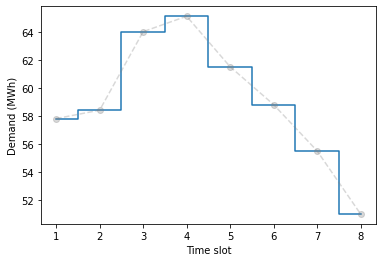

In [2]:
Gm_df=pd.read_excel('Data_0.xlsx',sheet_name='Gm') #Info generadores convencionales
Pd_df=pd.read_excel('Data_0.xlsx',sheet_name='Pd')  #Info Carga estatica
Lt_df=pd.read_excel('Data_0.xlsx',sheet_name='Lt') #Info Transacciones de energía
Wi_df=pd.read_excel('Data_0.xlsx',sheet_name='Wi') #Info generadores FCNER

#Se crean las variables a partir de la información de los datasets

#Info de generadores convencionales
Gm_min=np.array(Gm_df['Pg_min'].values)
Gm_max=np.array(Gm_df['Pg_max'].values)
am=np.array(Gm_df['a_m'].values)
bm=np.array(Gm_df['b_m'].values)


#Info de Carga estatica
Pd_min=np.array(Pd_df['Pd_min'].values)
Pd_max=np.array(Pd_df['Pd_max'].values)
cn=np.array(Pd_df['c_n'].values)
dn=np.array(Pd_df['d_n'].values)

#info de Balance de potencia

Lt=np.array(Lt_df['Lt'].values)
alpha=np.array(Lt_df['alpha'].values)
betha=np.array(Lt_df['beta'].values)

Al = np.array([(alpha[i]-betha[i])/2 for i in range(len(alpha))] ) # creamos una lista vacía
Bl=  np.array([(alpha[i]+betha[i])/2 for i in range(len(alpha))] ) 

#Info de generadores eolicos
w1=np.array(Wi_df['w_1'].values)
w2=np.array(Wi_df['w_2'].values)

#Se declara variable T, en representación al tiempo, M generadores, N cargas
T=len(Lt)
M=len(am)
N=len(cn)

# Se grafica la carga a utilizar a lo largo de los T periodos de tiempo.
plt.plot(Lt_df.index+1, Lt_df['Lt'],drawstyle='steps-mid') 
plt.plot(Lt_df.index+1, Lt_df['Lt'], 'o--', color='grey', alpha=0.3)
plt.xlabel('Time slot')
plt.ylabel('Demand (MWh)')
plt.show()

In [3]:
am.shape

(3,)

In [ ]:
from rsome import ro #Se importa la librería de Optimización Robusta
from rsome import eco_solver as eco #Se selecciona la interfaz ecos para solucionar problemas de optimization
from rsome import msk_solver as msk
import rsome as rso

from rsome import dro
from rsome import norm
from rsome import E

# se crea modelo en RSOME

model=ro.Model('NMGs') #Modelo llamado NMGs

#Se crean las variables de desición
'''
Decision Variables and Linear Constraints
Decision variables of a model can be defined by the method dvar().
Parameters
    ----------
    shape : int or tuple
        Shape of the variable array.
    vtype : {'C', 'B', 'I'}
        Type of the decision variables. 'C' means continuous; 'B'
        means binary, and 'I" means integer.
    name : str
        Name of the variable array
    aux : leave it unspecified.

    Returns
    -------
    new_var : rsome.lp.Vars
        An array of new decision variables
'''
#se crean las variables de decisión Pgm
Pgm=model.dvar(shape=(T,M),name='Pgm') #Se define variable de decisión Pgm de la forma [3x8]
Pdn=model.dvar(shape=(T,N),name='Pdn')#Se define variable de decisión Pdn de la forma [6x8]
Pr=model.dvar(shape=(T,),name='Pr')#Se define variable de decisión Pr de la forma [1x8]

In [5]:
# Cgm=(am*Pgm+bm*Pgm).sum()-(cn*Pdn).sum()
# Cgm

In [6]:
#Se crea Función G(Pr,Wi)
Gf=(Al*(Pr-w1-w2)).sum()
Gf

an affine expression

In [8]:
Pgmn=am**0.5*Pgm 
Ctm=rso.sumsqr(Pgmn.reshape(-1))+(bm*Pgm).sum()
Udn=(cn*Pdn).sum() #Modifica las dimensiones de la matriz convirtiendola en un vector
model.min(Ctm-Udn+Gf)

In [9]:
Pgmn.reshape(-1)

24 affine expressions

In [10]:
for col in Pgm: #Restr. 1
    model.st(Gm_max <= col,
             Pgm<=Gm_max)
for col in Pdn: #Restr. 3
    model.st(Pd_min >= col,
             col<=Pd_max)
for col in Pr.T: #Restr. 4
    model.st(1 >= col,
             col<=40)
# for t in range(T):
#    model.st(sum(Pgm[t])+Pr==Lt[t]+Pdn[t].sum())
for col in Pgm:
  model.st((Gm_max-col).sum()>=10)

In [13]:
model.solve(msk)

TypeError: Incorrect type for the objective function.

In [ ]:
Pdn.get()

RuntimeError: No solution available. Scipy solution status: 2.